In [ ]:
# %pip install seaborn

from pathlib import Path
import geopandas as gpd
print(gpd.__version__)


# ---------------------------
# Input files
# ---------------------------
root = Path(r"C:\Users\yingjiel\Documents\mongolia-mining")
dir = root / "data"
mining_fp   = dir / 'raw/_mining-viz/Tang_v2_7894216' / "74548_projected polygons.shp";              data_label = "Tang2023"
mining_fp   = dir / 'raw/_mining-viz/Maus-etal_2022_V2_allfiles' / "global_mining_polygons_v2.gpkg"; data_label = "Maus2022"
mongolia_fp = dir / "ne_50m_admin_0_countries_MNG.shp"


Note: you may need to restart the kernel to use updated packages.
1.1.1


# Load data - clip to AOI

In [5]:

# ---------------------------
# Read data
# ---------------------------
mines = gpd.read_file(mining_fp)
mongolia = gpd.read_file(mongolia_fp)

# ---------------------------
# Make sure both layers use the same CRS
# ---------------------------
if mines.crs != mongolia.crs:
    mongolia = mongolia.to_crs(mines.crs)

# ---------------------------
# If Mongolia boundary has multiple parts, dissolve to one geometry
# ---------------------------
mongolia_union = mongolia.union_all()

# ---------------------------
# Keep mining polygons that intersect Mongolia
# This includes:
# - fully within Mongolia
# - partially overlapping Mongolia
# - touching the boundary
# ---------------------------
mines_mongolia = mines[mines.intersects(mongolia_union)].copy()

# ---------------------------
# Save output
# ---------------------------
out_fp = dir / 'mining_polygons_clipped' / (f"mining_polygons_{data_label}.gpkg"); 
mines_mongolia.to_file(out_fp, driver="GPKG")

print(f"Original mining polygons: {len(mines)}")
print(f"Selected mining polygons: {len(mines_mongolia)}")
print(f"Saved to: {out_fp}")

Original mining polygons: 44929
Selected mining polygons: 429
Saved to: D:\natcap\mongolia-mining\data\mining_polygons_clipped\mining_polygons_Maus2022.gpkg


# Stats

In [ ]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Input clipped polygon file
# -------------------------

# run each dataset separately by changing the data_label and file path
data_label = "Tang2023"
data_label = "Maus2022"

fp = dir / 'mining_polygons_clipped' / (f"mining_polygons_{data_label}.gpkg")

# -------------------------
# Load polygon data
# -------------------------
gdf = gpd.read_file(fp)

# print(gdf.head())
# print(gdf.crs)
print(f"Number of polygons: {len(gdf)}")

# -------------------------
# Reproject if needed
# Area should be calculated in a projected CRS, not geographic CRS
# Example: EPSG:3857 or better a Mongolia-appropriate projected CRS
# -------------------------
if gdf.crs.is_geographic:
    print("Input is in geographic CRS. Reprojecting to EPSG:3857 for area calculation...")
    gdf = gdf.to_crs(3857)

# -------------------------
# Calculate polygon area
# -------------------------
gdf["area_m2"] = gdf.geometry.area
gdf["area_km2"] = gdf["area_m2"] / 1e6
print(gdf.head())


Number of polygons: 557
   OBJECTID    Name    Shape_Le_1    Shape_Area  \
0         2      Au  22248.346547  6.566996e+06   
1         4      Fe   8281.186849  2.323061e+06   
2      1397  未命名多边形  15590.504960  3.874405e+06   
3      1398  未命名多边形  13497.361155  7.793804e+06   
4      1399  未命名多边形   2636.997699  3.380635e+05   

                                            geometry       area_m2  area_km2  
0  POLYGON Z ((10362412.948 5571579.856 0, 103631...  6.566996e+06  6.566996  
1  POLYGON Z ((11034240.022 5539946.449 0, 110342...  2.323061e+06  2.323061  
2  POLYGON Z ((9801448.082 5242441.245 0, 9801333...  3.874405e+06  3.874405  
3  POLYGON Z ((9229181.447 5229539.445 0, 9229134...  7.793804e+06  7.793804  
4  POLYGON Z ((9139390.464 5251278.591 0, 9139400...  3.380635e+05  0.338064  



Area statistics (km²):
count    557.000000
mean       0.837668
std        3.173466
min        0.000257
25%        0.024820
50%        0.111032
75%        0.543870
max       51.530878
Name: area_km2, dtype: float64

Additional stats:
Total area (km²): 466.581
Median area (km²): 0.111
Std dev area (km²): 3.173

Saved attribute table with area column to: D:\natcap\mongolia-mining\data\mining_polygons_clipped\mining_polygons_Tang2023_area_stats.csv
Saved summary to: D:\natcap\mongolia-mining\data\mining_polygons_clipped\mining_polygons_Tang2023_area_summary_stats.csv


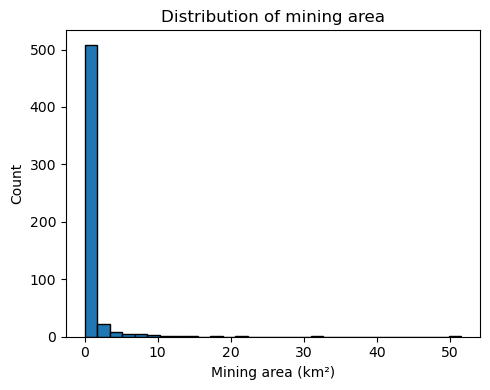

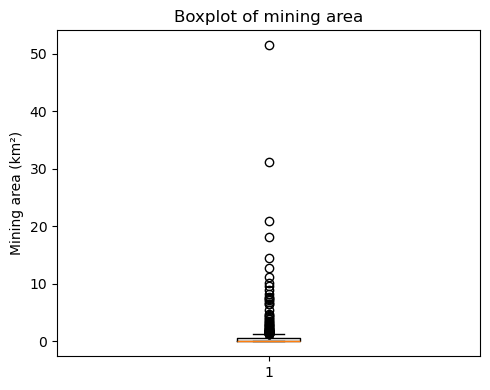

In [49]:

# -------------------------
# Summary statistics
# -------------------------
stats = gdf["area_km2"].describe()
print("\nArea statistics (km²):")
print(stats)

print("\nAdditional stats:")
print(f"Total area (km²): {gdf['area_km2'].sum():.3f}")
print(f"Median area (km²): {gdf['area_km2'].median():.3f}")
print(f"Std dev area (km²): {gdf['area_km2'].std():.3f}")

# -------------------------
# Save area table if needed
# -------------------------
out_csv = fp.with_name(fp.stem + "_area_stats.csv")
gdf.drop(columns="geometry").to_csv(out_csv, index=False)
print(f"\nSaved attribute table with area column to: {out_csv}")


# -------------------------
# Save summary statistics to CSV
# -------------------------
import pandas as pd
from pathlib import Path

summary_df = pd.DataFrame({
    "metric": ["count", "min", "max", "mean", "median", "std", "sum"],
    "area_km2": [
        gdf["area_km2"].count(),
        gdf["area_km2"].min(),
        gdf["area_km2"].max(),
        gdf["area_km2"].mean(),
        gdf["area_km2"].median(),
        gdf["area_km2"].std(),
        gdf["area_km2"].sum()
    ]
})

# Save
out_csv = fp.with_name(fp.stem + "_area_summary_stats.csv"); 
summary_df.to_csv(out_csv, index=False)
print(f"Saved summary to: {out_csv}") 



# -------------------------
# Histogram of polygon area
# -------------------------
plt.figure(figsize=(5, 4))
plt.hist(gdf["area_km2"], bins=30, edgecolor="black")
plt.xlabel("Mining area (km²)")
plt.ylabel("Count")
plt.title("Distribution of mining area")
plt.tight_layout()
plt.show()



# -------------------------
# Boxplot of polygon area
# -------------------------
plt.figure(figsize=(5, 4))
plt.boxplot(gdf["area_km2"], vert=True)
plt.ylabel("Mining area (km²)")
plt.title("Boxplot of mining area")
plt.tight_layout()
plt.show()

# Viz

## Point map

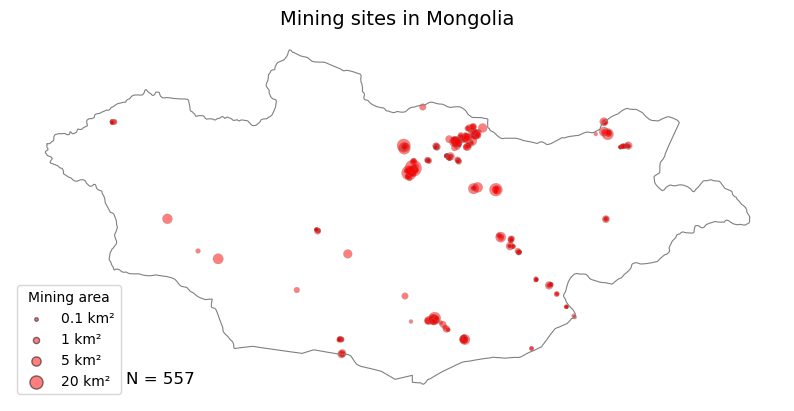

Saved figure to: D:\natcap\mongolia-mining\data\mining_polygons_clipped\mining_polygons_Tang2023_points_map.png


In [51]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# Convert polygons to representative points
# representative_point() is safer than centroid for visualization
# -------------------------
points = gdf.copy()
points["geometry"] = points.geometry.representative_point()

# -------------------------
# Scale marker sizes
# Use sqrt so very large polygons do not dominate too much
# -------------------------
points["plot_size"] = np.sqrt(points["area_km2"]) * 20  # scaling factor to adjust overall size
# points["plot_size"] = np.log1p(points["area_km2"]) * 30 # alternative scaling using log to reduce skewness

# Optional: minimum marker size
points["plot_size"] = points["plot_size"].clip(lower=8)

# Step 4: project for plotting
points = points.to_crs(4326)
boundary = gpd.read_file(mongolia_fp).to_crs(points.crs)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Mongolia's boundary
boundary.boundary.plot(ax=ax, color="gray", linewidth=0.8)

# Plot points with size scaled by area
points.plot(
    ax=ax,
    markersize=points["plot_size"],
    color="red",
    alpha=0.5,
    edgecolor="gray",
    linewidth=0.3
)


# ---- Add total count ----
total_n = len(points)
ax.text(
    0.15, 0.08, # bottom right corner
    f"N = {total_n}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)


# ---- Legend ----
legend_sizes_km2 = [0.1, 1, 5, 20]
legend_sizes_plot = [np.sqrt(s) * 20 for s in legend_sizes_km2]

handles = [
    plt.scatter([], [], s=size, color="red", alpha=0.5, edgecolor="black")
    for size in legend_sizes_plot
]

labels = [f"{s} km²" for s in legend_sizes_km2]

ax.legend(handles, labels, title="Mining area", loc="lower left")

# ---- Final styling ----
ax.set_title("Mining sites in Mongolia", fontsize=14)
ax.set_axis_off()

# -------------------------
# Save high-quality figure for PowerPoint
# -------------------------
out_png = fp.with_name(fp.stem + "_points_map.png")
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

print(f"Saved figure to: {out_png}")

# LULC change

In [4]:
# %pip install matplotlib

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from typing import Dict, Tuple, List
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# User inputs
# ============================================================


# Load mining polygons
#   run each dataset separately by changing the data_label and file path
data_label = "Tang2023"
data_label = "Maus2022"

mining_fp = dir / 'mining_polygons_clipped' / (f"mining_polygons_{data_label}.gpkg")

# Load LULC data
lulc_2000_fp = dir / 'LULC/MON_LULC' / "2000.tif"
lulc_2020_fp = dir / 'LULC/MON_LULC' / "2020.tif"

# Set output directory
out_dir = dir / 'lulc_change_outputs'
out_dir.mkdir(parents=True, exist_ok=True)

# Optional class labels; update to your real scheme
LULC_CLASSES = {
    1: "Forest",
    2: "Shrub",
    3: "Meadow",        # sub-classe of grassland
    4: "Real steppe",   # sub-classe of grassland
    5: "Dry steppe",    # sub-classe of grassland
    6: "Desert steppe", # sub-classe of grassland
    7: "Wetland",
    8: "Water",
    9: "Cropland",
    10: "Built-up land",
    11: "Barren land",  # sub-classe of bare areas
    12: "Desert",       # sub-classe of bare areas
    13: "Sand",         # sub-classe of bare areas
    14: "Ice"
}


# Optional: grouped classes
LULC_GROUPS = {
    1: "Forest",
    2: "Shrub",
    3: "Grassland",
    4: "Grassland",
    5: "Grassland",
    6: "Grassland",
    7: "Wetland",
    8: "Water",
    9: "Cropland",
    10: "Built-up",
    11: "Bare areas",
    12: "Bare areas",
    13: "Bare areas",
    14: "Ice"
}

# Optional colors for plotting; update to your real scheme
CLASS_COLORS = {
    1: "#228B22",  # Forest
    2: "#66CDAA",  # Shrub
    3: "#ADFF2F",  # Meadow
    4: "#7CFC00",  
    5: "#9ACD32",
    6: "#556B2F",
    7: "#00CED1",  # Wetland
    8: "#1E90FF",  # Water
    9: "#FFD700",  # Cropland
    10: "#FF4500", # Built-up
    11: "#D2B48C", # Barren
    12: "#EDC9AF",
    13: "#F4A460",
    14: "#E0FFFF"
}


## Functions

In [5]:
def load_lulc_raster(filepath: Path) -> Tuple[np.ndarray, dict, rasterio.DatasetReader]:
    """
    Load LULC raster file.
    
    Returns:
        data: numpy array of LULC values
        profile: rasterio profile (metadata)
        src: rasterio dataset object
    """
    src = rasterio.open(filepath)
    data = src.read(1)
    profile = src.profile
    return data, profile, src


def load_mining_polygons(filepath: Path) -> gpd.GeoDataFrame:
    """Load mining site polygons from GeoPackage or shapefile."""
    gdf = gpd.read_file(filepath)
    # Ensure CRS is defined; reproject if needed
    if gdf.crs is None:
        print("Warning: No CRS defined. Assuming EPSG:4326")
        gdf = gdf.set_crs("EPSG:4326")
    return gdf


def clip_raster_to_polygons(raster_data: np.ndarray, 
                             raster_src: rasterio.DatasetReader,
                             polygons: gpd.GeoDataFrame) -> Dict[int, np.ndarray]:
    """
    Clip raster data to mining polygon boundaries.
    
    Returns:
        dict mapping polygon index to clipped raster array
    """
    clipped_data = {}
    
    for idx, row in polygons.iterrows():
        geom = [row.geometry]
        try:
            # Clip raster to polygon
            clipped, transform = mask(raster_src, geom, crop=True)
            clipped_data[idx] = clipped[0]  # Extract first band
        except Exception as e:
            print(f"Warning: Could not clip polygon {idx}: {e}")
            clipped_data[idx] = None
    
    return clipped_data


def calculate_lulc_distribution(raster_data: np.ndarray, 
                                 pixel_area_m2: float) -> pd.DataFrame:
    """
    Calculate area and percentage of each LULC class.
    
    Args:
        raster_data: numpy array of LULC values
        pixel_area_m2: pixel area in square meters
        
    Returns:
        DataFrame with class statistics
    """
    unique, counts = np.unique(raster_data, return_counts=True)
    
    stats_list = []
    for class_id, count in zip(unique, counts):
        if class_id == 0:  # Skip nodata/background
            continue
        
        area_m2 = count * pixel_area_m2
        area_km2 = area_m2 / 1e6
        
        stats_list.append({
            'Class_ID': int(class_id),
            'Class_Name': LULC_CLASSES.get(int(class_id), f'Unknown ({class_id})'),
            'Pixel_Count': int(count),
            'Area_m2': area_m2,
            'Area_km2': area_km2
        })
    
    df = pd.DataFrame(stats_list)
    if len(df) > 0:
        total_area = df['Area_km2'].sum()
        df['Percentage'] = (df['Area_km2'] / total_area * 100).round(2)
    
    return df


def create_transition_matrix(raster_2000: np.ndarray, 
                            raster_2020: np.ndarray,
                            pixel_area_m2: float) -> pd.DataFrame:
    """
    Create LULC transition/change matrix for 2000-2020.
    
    Returns:
        DataFrame with from/to class transitions and areas
    """
    # Flatten arrays
    data_2000_flat = raster_2000.flatten()
    data_2020_flat = raster_2020.flatten()
    
    # Create transition matrix
    transitions = []
    
    unique_2000 = np.unique(data_2000_flat)
    unique_2020 = np.unique(data_2020_flat)
    all_classes = np.unique(np.concatenate([unique_2000, unique_2020]))
    
    for class_from in all_classes:
        if class_from == 0:
            continue
        for class_to in all_classes:
            if class_to == 0:
                continue
            
            # Count pixels that transitioned
            count = np.sum((data_2000_flat == class_from) & (data_2020_flat == class_to))
            
            if count > 0:
                area_m2 = count * pixel_area_m2
                area_km2 = area_m2 / 1e6
                
                transitions.append({
                    'From_Class': int(class_from),
                    'From_Name': LULC_CLASSES.get(int(class_from), f'Unknown ({class_from})'),
                    'To_Class': int(class_to),
                    'To_Name': LULC_CLASSES.get(int(class_to), f'Unknown ({class_to})'),
                    'Pixel_Count': int(count),
                    'Area_km2': area_km2,
                    'Change_Type': 'Stable' if class_from == class_to else 'Changed'
                })
    
    return pd.DataFrame(transitions)


def calculate_change_metrics(lulc_2000_df: pd.DataFrame,
                             lulc_2020_df: pd.DataFrame,
                             transition_df: pd.DataFrame) -> Dict:
    """Calculate key change metrics and statistics."""
    
    # Merge 2000 and 2020 data
    merged = pd.merge(
        lulc_2000_df[['Class_ID', 'Area_km2']].rename(columns={'Area_km2': 'Area_2000_km2'}),
        lulc_2020_df[['Class_ID', 'Area_km2']].rename(columns={'Area_km2': 'Area_2020_km2'}),
        on='Class_ID',
        how='outer'
    ).fillna(0)
    
    merged['Change_km2'] = merged['Area_2020_km2'] - merged['Area_2000_km2']
    merged['Change_pct'] = (merged['Change_km2'] / (merged['Area_2000_km2'] + 1e-6) * 100).round(2)
    
    # Calculate total change statistics
    stable_area = transition_df[transition_df['Change_Type'] == 'Stable']['Area_km2'].sum()
    changed_area = transition_df[transition_df['Change_Type'] == 'Changed']['Area_km2'].sum()
    total_area = stable_area + changed_area
    
    metrics = {
        'Total_Mining_Area_km2': total_area,
        'Stable_Area_km2': stable_area,
        'Changed_Area_km2': changed_area,
        'Stability_Percentage': (stable_area / total_area * 100) if total_area > 0 else 0,
        'Change_Percentage': (changed_area / total_area * 100) if total_area > 0 else 0,
        'Class_Changes': merged
    }
    
    return metrics

## Load data

In [4]:

# ============================================================
# Load mining polygons
# ============================================================
mines = gpd.read_file(mining_fp)

if mines.empty:
    raise ValueError("Mining polygon layer is empty.")

# --------------------------------------------------
# Mask both rasters
# --------------------------------------------------
arr2000, transform2000, nodata2000 = mask_raster_to_polygons(lulc_2000_fp, mines)
arr2020, transform2020, nodata2020 = mask_raster_to_polygons(lulc_2020_fp, mines)

# Check same masked grid
if arr2000.shape != arr2020.shape or transform2000 != transform2020:
    raise ValueError("Masked 2000 and 2020 rasters are not aligned. They need the same grid.")

pixel_area_km2 = abs(transform2000.a * transform2000.e) / 1e6


ValueError: Masked 2000 and 2020 rasters are not aligned. They need the same grid.

## Summary stats

In [ ]:
# --------------------------------------------------
# Per-year summaries
# --------------------------------------------------
sum2000 = summarize_classes(arr2000, pixel_area_km2, nodata2000).rename(
    columns={"pixel_count": "pixel_count_2000", "area_km2": "area_km2_2000"}
)

sum2020 = summarize_classes(arr2020, pixel_area_km2, nodata2020).rename(
    columns={"pixel_count": "pixel_count_2020", "area_km2": "area_km2_2020"}
)

summary = (
    pd.merge(sum2000[["class_code", "class_name", "pixel_count_2000", "area_km2_2000"]],
             sum2020[["class_code", "pixel_count_2020", "area_km2_2020"]],
             on="class_code", how="outer")
    .fillna(0)
    .sort_values("class_code")
)

summary["class_name"] = summary["class_code"].map(LULC_CLASSES).fillna(summary["class_code"].astype(str))
summary["change_km2"] = summary["area_km2_2020"] - summary["area_km2_2000"]
summary["pct_change"] = np.where(
    summary["area_km2_2000"] > 0,
    summary["change_km2"] / summary["area_km2_2000"] * 100,
    np.nan
)

: 

## Change detection

In [ ]:
# --------------------------------------------------
# Transition table
# --------------------------------------------------
valid = np.ones(arr2000.shape, dtype=bool)
if nodata2000 is not None:
    valid &= (arr2000 != nodata2000)
if nodata2020 is not None:
    valid &= (arr2020 != nodata2020)

transition = (
    pd.DataFrame({
        "from_2000": arr2000[valid].astype(int),
        "to_2020": arr2020[valid].astype(int)
    })
    .value_counts()
    .reset_index(name="pixel_count")
)

transition["area_km2"] = transition["pixel_count"] * pixel_area_km2
transition["from_name"] = transition["from_2000"].map(LULC_CLASSES)
transition["to_name"] = transition["to_2020"].map(LULC_CLASSES)

transition_matrix = transition.pivot_table(
    index="from_2000",
    columns="to_2020",
    values="area_km2",
    fill_value=0
)


## Overall stats and export results

In [ ]:
# --------------------------------------------------
# Overall stats
# --------------------------------------------------
overall = pd.DataFrame({
    "metric": [
        "n_mining_polygons",
        "total_area_km2_2000",
        "total_area_km2_2020",
        "changed_area_km2",
        "pct_area_changed"
    ],
    "value": [
        len(mines),
        summary["area_km2_2000"].sum(),
        summary["area_km2_2020"].sum(),
        (arr2000[valid] != arr2020[valid]).sum() * pixel_area_km2,
        (arr2000[valid] != arr2020[valid]).mean() * 100
    ]
})

# --------------------------------------------------
# Export CSVs
# --------------------------------------------------
summary.to_csv(out_dir / "lulc_summary_2000_2020.csv", index=False)
transition.to_csv(out_dir / "lulc_transition_pairs_2000_2020.csv", index=False)
transition_matrix.to_csv(out_dir / "lulc_transition_matrix_km2.csv")
overall.to_csv(out_dir / "lulc_overall_stats.csv", index=False)


In [ ]:

# --------------------------------------------------
# Figures
# --------------------------------------------------
# 1. Area by class in 2000 and 2020
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w/2, summary["area_km2_2000"], width=w, label="2000")
ax.bar(x + w/2, summary["area_km2_2020"], width=w, label="2020")
ax.set_xticks(x)
ax.set_xticklabels(summary["class_name"], rotation=45, ha="right")
ax.set_ylabel("Area within mining sites (km²)")
ax.set_title("LULC within mining sites: 2000 vs 2020")
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "fig_lulc_2000_vs_2020.png", dpi=400, bbox_inches="tight")
plt.close()

# 2. Net change
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(summary["class_name"], summary["change_km2"])
ax.set_ylabel("Net change (km²)")
ax.set_title("Net LULC change within mining sites, 2000–2020")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(out_dir / "fig_lulc_net_change.png", dpi=400, bbox_inches="tight")
plt.close()

# 3. Transition heatmap
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(transition_matrix.values)
ax.set_xticks(np.arange(len(transition_matrix.columns)))
ax.set_yticks(np.arange(len(transition_matrix.index)))
ax.set_xticklabels([LULC_CLASSES.get(c, str(c)) for c in transition_matrix.columns], rotation=45, ha="right")
ax.set_yticklabels([LULC_CLASSES.get(c, str(c)) for c in transition_matrix.index])
ax.set_xlabel("2020 class")
ax.set_ylabel("2000 class")
ax.set_title("LULC transition matrix within mining sites (km²)")
fig.colorbar(im, ax=ax, label="Area (km²)")
plt.tight_layout()
plt.savefig(out_dir / "fig_lulc_transition_matrix.png", dpi=400, bbox_inches="tight")
plt.close()

print("Done.")
print(f"Outputs saved to: {out_dir}")
print(summary)
print(overall)